## Notebook P3-05: MCD-rPPG Phase-3 Preprocessing

### What this notebook does
Maps the MCD-rPPG dataset (frontal FullHDwebcam view) into the unified Phase-3 schema: one consolidated HDF5 with one group per recording. Frames are decoded from the .avi videos and face-cropped; the frame-synced BVP comes from ppg_sync; ECG is stored for a later EDR-based respiration reference; and the clinical biomarkers from db.csv are stored as per-recording attributes.

### Role in Phase 3
MCD-rPPG is the primary TRAINING set (600 subjects x 2 states, resting and post-exercise). It feeds the HR head via the BVP waveform. Its ECG enables a later EDR-derived respiration label; the db.csv respiratory rate is a single clinical scalar (stored as an attribute), so the RR head is masked in this first pass. Only the frontal view (FullHDwebcam, labelled view=front) is used, to match the webcam deployment domain.

### Reminder on the HR distribution
MCD includes post-exercise recordings, which skew HR high — the cause of the Phase-2 model's shrinkage / high bias for resting users. The resting/post-exercise state is stored per recording so training can balance the distribution and report the resting subset separately.

### Pipeline
db.csv (frontal rows) -> for each recording:
  decode video (.avi) -> MediaPipe face box (stable, from sampled frames) -> crop + resize to 128
  ppg_sync -> per-frame BVP label (aligned to frame count)
  ecg json -> ECG waveform (stored for later EDR)
  db.csv row -> biomarkers as bm_ attributes; state from step (before/after)
  -> write one group per recording into the consolidated MCD Phase-3 HDF5 


### Unified Phase-3 schema (v1) — MCD specifics
Same grouped layout as the other Phase-3 datasets. For MCD each recording group holds:

| name | source | present | notes |
|------|--------|---------|-------|
| frames | face-cropped .avi | yes | [T, 128, 128, 3] uint8 |
| bvp | ppg_sync | yes | per-frame PPG, frame-synced HR label |
| ecg | ecg json | yes | ~500 Hz waveform, for later EDR-based RR |
| resp | — | no (masked) | only a clinical scalar exists (bm_respiratory_rate) |

Biomarkers from db.csv are stored as attributes with a bm_ prefix (bm_pulse = HR, bm_respiratory_rate, bm_spo2, bm_systolic_bp, bm_diastolic_bp, bm_temperature, bm_hemoglobin, bm_glycated_hb, bm_cholesterol, bm_arterial_stiffness, bm_stress, bm_age, bm_sex, bm_bmi, ...). Availability flags (has_frames / has_bvp / has_ecg / has_resp) drive masked multi-task supervision; graded quality (cardiac_sqi) is kept rather than hard-dropping.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import h5py
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

MCD_DIR = Path('G:/rppg/MCD_rPPG_dataset')
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
MP_MODEL = REPO_ROOT / 'app' / 'live_hr_demo' / 'models' / 'mediapipe' / 'face_landmarker.task'
DATASET_NAME = 'mcd'
OUT_DIR = Path('G:/rppg/phase3') # large outputs on the G: data drive
OUT_H5 = OUT_DIR / f'{DATASET_NAME}_phase3.h5'
LOG_PATH = OUT_DIR / f'processing_log_{DATASET_NAME}_phase3.csv'
OUT_DIR.mkdir(parents=True, exist_ok=True)

VIEW = 'front' # frontal webcam (FullHDwebcam) — the app-relevant view
TARGET_SIZE = 72
CROP_PADDING = 0.6 # expand the face box (include forehead + cheeks)
N_DETECT_FRAMES = 12 # frames sampled to compute a stable face box
FPS_FALLBACK = 30.0
CARDIAC_LOW_HZ, CARDIAC_HIGH_HZ = 0.7, 3.5

# Quality thresholds
MIN_DURATION_S = 20.0
SQI_FLOOR = 0.05
FRAME_DARK, FRAME_BRIGHT = 5.0, 250.0

SCHEMA_VERSION = 'p3_v1'
OVERWRITE = False
MAX_RECORDS =  None # set to an int for a trial run

print('MCD dir exists:', MCD_DIR.exists())
print('MediaPipe model exists:', MP_MODEL.exists())
print('Output store:', OUT_H5)

MCD dir exists: True
MediaPipe model exists: True
Output store: G:\rppg\phase3\mcd_phase3.h5


In [2]:
BM_MAP = {
    'pulse': 'bm_pulse', 'respiratory': 'bm_respiratory_rate', 'saturation': 'bm_spo2',
    'upper_ap': 'bm_systolic_bp', 'lower_ap': 'bm_diastolic_bp', 'temperature': 'bm_temperature',
    'hemoglobin': 'bm_hemoglobin', 'glycated_hemoglobin': 'bm_glycated_hb', 'cholesterol': 'bm_cholesterol',
    'rigidity': 'bm_arterial_stiffness', 'stress': 'bm_stress', 'age': 'bm_age', 'sex': 'bm_sex',
    'bmi': 'bm_bmi', 'weight': 'bm_weight', 'height': 'bm_height', 'step': 'bm_step'}


def load_frame_series(path):
    '''Reads the first whitespace-separated column of a text file, skipping blank lines.'''
    out = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                out.append(float(line.split()[0]))
    return np.asarray(out, dtype=np.float32)


def cardiac_metrics(sig, fps, low=CARDIAC_LOW_HZ, high=CARDIAC_HIGH_HZ):
    '''Returns the cardiac-band spectral HR (bpm) and a 3-bin peak-power fraction SQI from a pulse waveform.'''
    x = np.asarray(sig, dtype=np.float64)
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan, 0.0
    x = (x - x.mean()) * np.hanning(x.size)
    power = np.abs(np.fft.rfft(x)) ** 2
    freqs = np.fft.rfftfreq(x.size, d=1.0 / fps)
    band = (freqs >= low) & (freqs <= high)
    if not band.any() or power[band].sum() <= 0:
        return np.nan, 0.0
    bp = power[band]
    pk = int(np.argmax(bp))
    return float(freqs[band][pk] * 60.0), float(bp[max(0, pk - 1):pk + 2].sum() / bp.sum())


def fps_from_meta(meta_path, n_frames, fallback=FPS_FALLBACK):
    '''Estimates fps from the meta frame-timestamp file; falls back to a default on any problem.'''
    try:
        ts = []
        with open(meta_path) as f:
            for line in f:
                parts = line.strip().split(maxsplit=1)
                if len(parts) == 2:
                    ts.append(pd.Timestamp(parts[1]).value)
        if len(ts) > 10:
            dt = np.median(np.diff(ts)) / 1e9
            if dt > 0:
                return float(1.0 / dt)
    except Exception:
        pass
    return fallback


def load_ecg(path):
    '''Loads the first ECG lead values and sampling frequency from the JSON, or (None, 0.0).'''
    try:
        with open(path) as f:
            j = json.load(f)
        fs = float(j.get('frequency', 500))
        data = j.get('data', [])
        if data and 'values' in data[0]:
            return np.asarray(data[0]['values'], dtype=np.float32), fs
    except Exception:
        pass
    return None, 0.0

In [3]:
def make_landmarker():
    '''Creates a MediaPipe FaceLandmarker in single-image mode.'''
    opts = mp_vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=str(MP_MODEL)),
        running_mode=mp_vision.RunningMode.IMAGE, num_faces=1)
    return mp_vision.FaceLandmarker.create_from_options(opts)


def stable_face_box(frames_rgb, landmarker, padding=CROP_PADDING):
    '''Returns a square relative face box (rx0, ry0, rx1, ry1) as the median detection over sample frames.'''
    boxes = []
    for frame in frames_rgb:
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(frame))
        res = landmarker.detect(mp_img)
        if not res.face_landmarks:
            continue
        lm = res.face_landmarks[0]
        xs = np.array([p.x for p in lm])
        ys = np.array([p.y for p in lm])
        boxes.append([xs.min(), ys.min(), xs.max(), ys.max()])
    if not boxes:
        return None
    x0, y0, x1, y1 = np.median(np.array(boxes), axis=0)
    cx, cy = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    half = max(x1 - x0, y1 - y0) * (1.0 + padding) / 2.0
    return (cx - half, cy - half, cx + half, cy + half)


def crop_resize(frame_rgb, box, size):
    '''Crops a frame to a relative square box (clamped to the frame) and resizes to size x size.'''
    h, w = frame_rgb.shape[:2]
    x0 = max(0, int(box[0] * w))
    y0 = max(0, int(box[1] * h))
    x1 = min(w, int(box[2] * w))
    y1 = min(h, int(box[3] * h))
    if x1 <= x0 or y1 <= y0:
        return None
    crop = frame_rgb[y0:y1, x0:x1]
    return cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA)


def extract_face_frames(video_path, landmarker, size=TARGET_SIZE, n_detect=N_DETECT_FRAMES):
    '''Decodes a video, computes a stable face box from sampled frames, and returns cropped size x size frames.'''
    cap = cv2.VideoCapture(str(video_path))
    n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if n_total <= 0:
        n_total = 100000
    sample_at = sorted(set(np.linspace(0, max(n_total - 1, 0), n_detect).astype(int)))
    samples = []
    for i in sample_at:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, bgr = cap.read()
        if ok:
            samples.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    box = stable_face_box(samples, landmarker) if samples else None
    if box is None:
        cap.release()
        return None
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    out = []
    while True:
        ok, bgr = cap.read()
        if not ok:
            break
        c = crop_resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), box, size)
        if c is not None:
            out.append(c)
    cap.release()
    if not out:
        return None
    return np.asarray(out, dtype=np.uint8)

### Single-recording walkthrough
Loads db.csv, filters to the frontal view, and processes one recording end to end (video decode, face-crop, ppg_sync BVP, ECG, biomarkers), printing the assembled record numerically. This validates the video/crop pipeline and the frame/BVP alignment before the full batch. No face imagery is rendered.

In [4]:
df = pd.read_csv(MCD_DIR / 'db.csv')
df_front = df[df['view'] == VIEW].reset_index(drop=True)
print('Total db rows:', len(df), '| frontal-view rows:', len(df_front))

LANDMARKER = make_landmarker()


def build_record(row):
    '''Builds one unified-schema record from a db.csv frontal-view row.'''
    bvp = load_frame_series(MCD_DIR / row['ppg_sync'])
    frames = extract_face_frames(MCD_DIR / row['video'], LANDMARKER)
    if frames is None or len(frames) == 0:
        raise RuntimeError('no frames or face not detected')
    n = min(len(frames), len(bvp))
    frames = frames[:n]
    bvp = bvp[:n].astype(np.float32)
    fps = fps_from_meta(MCD_DIR / row['meta'], n)
    bvp_hr, sqi = cardiac_metrics(bvp, fps)
    duration_s = n / fps
    brightness = float(frames[n // 2].mean())
    ecg_vals, ecg_fs = load_ecg(MCD_DIR / row['ecg'])
    attrs = dict(
        schema_version=SCHEMA_VERSION, dataset='MCD', source_file=Path(row['video']).name,
        subject_id=str(int(row['patient_id'])),
        state='post_exercise' if row['step'] == 'after' else 'rest',
        camera=str(row['camera']), view=str(row['view']),
        fps=float(fps), n_frames=int(n), duration_s=float(duration_s), frame_size=int(TARGET_SIZE),
        has_frames=True, has_bvp=True, has_hr=False, has_spo2=False,
        has_resp=False, has_ecg=bool(ecg_vals is not None),
        cardiac_sqi=float(sqi), bvp_spectral_hr=float(bvp_hr),
        frame_ok=bool(FRAME_DARK <= brightness <= FRAME_BRIGHT),
        usable=bool(duration_s >= MIN_DURATION_S and FRAME_DARK <= brightness <= FRAME_BRIGHT and sqi >= SQI_FLOOR),
        ecg_fs=float(ecg_fs),
        bvp_units_note='ppg_sync per-frame PPG (frame-aligned); loader applies bandpass and normalize')
    for col, name in BM_MAP.items():
        if col in row and pd.notna(row[col]):
            attrs[name] = str(row[col]) if col in ('sex', 'step') else float(row[col])
    rec_id = str(int(row['patient_id'])) + '_' + str(row['step'])
    arrays = dict(bvp=bvp, frames=frames, ecg=ecg_vals)
    return rec_id, arrays, attrs


rec_id, arrays, attrs = build_record(df_front.iloc[0])
print('record:', rec_id)
print(json.dumps({k: (round(v, 3) if isinstance(v, float) else v) for k, v in attrs.items()}, indent=2, default=str))
print('frames', arrays['frames'].shape, '| bvp', arrays['bvp'].shape,
      '| ecg', None if arrays['ecg'] is None else arrays['ecg'].shape)

Total db rows: 3600 | frontal-view rows: 1200
record: 1020_after
{
  "schema_version": "p3_v1",
  "dataset": "MCD",
  "source_file": "1020_FullHDwebcam_after.avi",
  "subject_id": "1020",
  "state": "post_exercise",
  "camera": "FullHDwebcam",
  "view": "front",
  "fps": 31.332,
  "n_frames": 5287,
  "duration_s": 168.74,
  "frame_size": 72,
  "has_frames": true,
  "has_bvp": true,
  "has_hr": false,
  "has_spo2": false,
  "has_resp": false,
  "has_ecg": true,
  "cardiac_sqi": 0.227,
  "bvp_spectral_hr": 81.072,
  "frame_ok": true,
  "usable": true,
  "ecg_fs": 500.0,
  "bvp_units_note": "ppg_sync per-frame PPG (frame-aligned); loader applies bandpass and normalize",
  "bm_pulse": 100.0,
  "bm_respiratory_rate": 19.0,
  "bm_spo2": 98.0,
  "bm_systolic_bp": 113.0,
  "bm_diastolic_bp": 78.0,
  "bm_temperature": 36.6,
  "bm_hemoglobin": 12.6,
  "bm_glycated_hb": 5.56,
  "bm_cholesterol": 4.3,
  "bm_arterial_stiffness": 10.79,
  "bm_stress": 4.0,
  "bm_age": 23.0,
  "bm_sex": "F",
  "bm_bm

### Write function and batch processing
Writes each frontal recording as a group in one consolidated MCD HDF5 on G:. Append mode with skip-existing makes it resumable; set OVERWRITE=True to rebuild, MAX_RECORDS for a trial run. MCD is a large frame set (~1200 frontal recordings at ~180 s), so a full run is long and storage-heavy — start with a small MAX_RECORDS and decide on frame size before committing to the full run.

In [5]:
def write_group(store, name, arrays, attrs):
    '''Writes one recording as a group with datasets for the present signals and all attributes.'''
    g = store.create_group(name)
    g.create_dataset('frames', data=arrays['frames'], compression='gzip', compression_opts=1)
    g.create_dataset('bvp', data=arrays['bvp'])
    if arrays.get('ecg') is not None:
        g.create_dataset('ecg', data=arrays['ecg'])
    for key, value in attrs.items():
        g.attrs[key] = value


def process_all(rows, out_h5, limit=None, overwrite=False):
    '''Processes frontal-view db rows into one consolidated per-dataset HDF5 (one group each).'''
    subset = rows.iloc[:limit] if limit else rows
    logs = []
    with h5py.File(out_h5, 'a') as store:
        for i in range(len(subset)):
            row = subset.iloc[i]
            name = str(int(row['patient_id'])) + '_' + str(row['step'])
            if name in store and not overwrite:
                a = dict(store[name].attrs)
                a['status'] = 'skipped'
                a['error'] = ''
            else:
                try:
                    rec_id, arrays, attrs = build_record(row)
                    if name in store:
                        del store[name]
                    write_group(store, name, arrays, attrs)
                    a = dict(attrs)
                    a['status'] = 'ok'
                    a['error'] = ''
                except Exception as exc:
                    a = dict(source_file=str(row['video']), subject_id=str(int(row['patient_id'])),
                             state='', cardiac_sqi=np.nan, usable=False, status='error', error=str(exc))
            cols = ('source_file', 'subject_id', 'state', 'n_frames', 'fps', 'duration_s',
                    'cardiac_sqi', 'bvp_spectral_hr', 'bm_pulse', 'bm_respiratory_rate',
                    'has_ecg', 'usable', 'status', 'error')
            logs.append({c: a.get(c) for c in cols})
            if (i + 1) % 25 == 0 or (i + 1) == len(subset):
                print('  processed', i + 1, '/', len(subset))
    return pd.DataFrame(logs)


log = process_all(df_front, OUT_H5, limit=MAX_RECORDS, overwrite=OVERWRITE)
log.to_csv(LOG_PATH, index=False)
print('Store:', OUT_H5)
print('Records ok:', int((log.status == 'ok').sum()), '| skipped:', int((log.status == 'skipped').sum()),
      '| errors:', int((log.status == 'error').sum()))
print('Usable:', int(log['usable'].sum()), '/', len(log))
print('Log ->', LOG_PATH)

  processed 25 / 1200
  processed 50 / 1200
  processed 75 / 1200
  processed 100 / 1200
  processed 125 / 1200
  processed 150 / 1200
  processed 175 / 1200
  processed 200 / 1200
  processed 225 / 1200
  processed 250 / 1200
  processed 275 / 1200
  processed 300 / 1200
  processed 325 / 1200
  processed 350 / 1200
  processed 375 / 1200
  processed 400 / 1200
  processed 425 / 1200
  processed 450 / 1200
  processed 475 / 1200
  processed 500 / 1200
  processed 525 / 1200
  processed 550 / 1200
  processed 575 / 1200
  processed 600 / 1200
  processed 625 / 1200
  processed 650 / 1200
  processed 675 / 1200
  processed 700 / 1200
  processed 725 / 1200
  processed 750 / 1200
  processed 775 / 1200
  processed 800 / 1200
  processed 825 / 1200
  processed 850 / 1200
  processed 875 / 1200
  processed 900 / 1200
  processed 925 / 1200
  processed 950 / 1200
  processed 975 / 1200
  processed 1000 / 1200
  processed 1025 / 1200
  processed 1050 / 1200
  processed 1075 / 1200
  processe

### Output validation
Re-opens the consolidated store, confirms the schema and biomarker attributes, verifies the frame tensor numerically (no face rendering), plots one BVP waveform, and summarizes the processing log by state.

Groups in mcd_phase3.h5 : 1200
Example group: 1020_after
  datasets: ['bvp', 'ecg', 'frames']
  attrs: {'bm_age': np.float64(23.0), 'bm_arterial_stiffness': np.float64(10.79), 'bm_bmi': np.float64(19.031141868512112), 'bm_cholesterol': np.float64(4.3), 'bm_diastolic_bp': np.float64(78.0), 'bm_glycated_hb': np.float64(5.56), 'bm_height': np.float64(170.0), 'bm_hemoglobin': np.float64(12.6), 'bm_pulse': np.float64(100.0), 'bm_respiratory_rate': np.float64(19.0), 'bm_sex': 'F', 'bm_spo2': np.float64(98.0), 'bm_step': 'after', 'bm_stress': np.float64(4.0), 'bm_systolic_bp': np.float64(113.0), 'bm_temperature': np.float64(36.6), 'bm_weight': np.float64(55.0), 'bvp_spectral_hr': np.float64(81.07152279082885), 'bvp_units_note': 'ppg_sync per-frame PPG (frame-aligned); loader applies bandpass and normalize', 'camera': 'FullHDwebcam', 'cardiac_sqi': np.float64(0.22707208656055075), 'dataset': 'MCD', 'duration_s': np.float64(168.739892), 'ecg_fs': np.float64(500.0), 'fps': np.float64(31.33224714

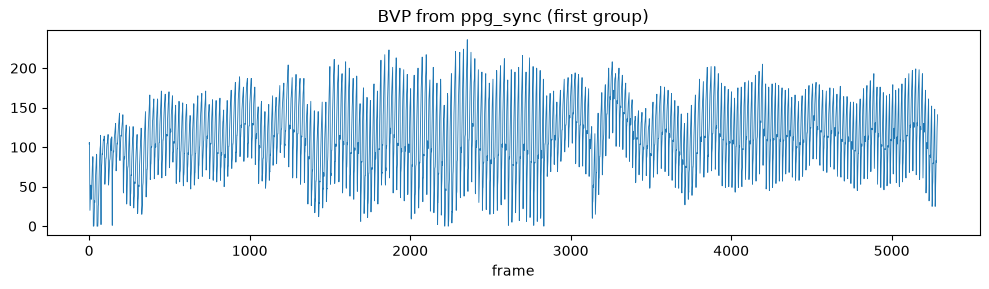

Usable rate by state:
state
post_exercise    0.990
rest             0.995

Mean cardiac SQI by state:
state
post_exercise    0.195
rest             0.190

Status counts: {'ok': np.int64(1200)}


In [6]:
if OUT_H5.exists():
    with h5py.File(OUT_H5, 'r') as store:
        groups = sorted(store.keys())
        print('Groups in', OUT_H5.name, ':', len(groups))
        g0 = store[groups[0]]
        print('Example group:', groups[0])
        print('  datasets:', list(g0.keys()))
        print('  attrs:', dict(g0.attrs))
        if 'frames' in g0:
            fr = g0['frames']
            print('  frames:', fr.shape, fr.dtype, 'range', int(fr[0].min()), '-', int(fr[0].max()))
        bvp0 = g0['bvp'][:]
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(np.arange(len(bvp0)), bvp0, lw=0.6)
    ax.set_title('BVP from ppg_sync (first group)')
    ax.set_xlabel('frame')
    plt.tight_layout()
    plt.show()

if len(log):
    print('Usable rate by state:')
    print(log.groupby('state')['usable'].mean().round(3).to_string())
    print()
    print('Mean cardiac SQI by state:')
    print(log.groupby('state')['cardiac_sqi'].mean().round(3).to_string())
    print()
    print('Status counts:', dict(log['status'].value_counts()))